# 3.2 Clustering — Segmentación de clientes de RetailMax

Aprendizaje **no supervisado** con el algoritmo **K-Means**.

El objetivo es identificar grupos (*clusters*) de clientes con caracteristicas en comun,
sin usar etiquetas predefinidas, para poder disenar estrategias de marketing personalizadas.

**Autor:** Claudio Loza

## Importar paquetes

In [1]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## Carga de datos

In [2]:
df = pd.read_csv('./data/retailmax.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


## Seleccion de features

Elegimos las variables que capturan el comportamiento del cliente:

- **Age** — influye en las preferencias de compra y el estilo de vida.
- **Annual Income (k$)** — indica el poder adquisitivo.
- **Spending Score (1-100)** — refleja los habitos de consumo dentro de la tienda.

Descartamos **CustomerID** porque es un identificador unico que no aporta informacion
comparable, y dejamos **Gender** fuera de momento por ser una variable categorica
(la incorporaremos al final).

In [4]:
features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
features.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


### Ojo con los indices

Al crear `features` quitamos columnas, pero **los indices se conservan**.
Esto sera clave para poder pegar los clusters de vuelta al DataFrame original.

In [5]:
df.sample(5, random_state=42)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
95,96,Male,24,60,52
15,16,Male,22,20,79
30,31,Male,60,30,4
158,159,Male,34,78,1
128,129,Male,59,71,11


In [6]:
features.sample(5, random_state=42)

,Age,Annual Income (k$),Spending Score (1-100)
95,24,60,52
15,22,20,79
30,60,30,4
158,34,78,1
128,59,71,11


## Estandarizacion

`StandardScaler` normaliza cada variable para que tenga media 0 y desviacion estandar 1.

Esto es **especialmente importante en K-Means**, que agrupa usando distancias euclidianas:
sin escalar, `Annual Income` (rango ~15-137) dominaria sobre `Age` y aplastaria la
contribucion de las demas variables.

In [7]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

### Inspeccion rapida

In [8]:
type(scaled_features)

numpy.ndarray

In [9]:
scaled_features.shape

(200, 3)

In [10]:
scaled_features[0:3]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298]])

Ya no son valores legibles a simple vista, pero sabemos que en cada array:
la posicion 0 es `Age`, la 1 es `Annual Income (k$)` y la 2 es `Spending Score (1-100)`.

## Creacion de clusters

Probamos primero con distintos valores de `k` para entender que hace el parametro.

### k = 3

In [11]:
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters = kmeans.fit_predict(scaled_features)
clusters

array([0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       2, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 0, 0, 2, 0, 0, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 2, 2, 0,
       2, 2, 0, 0, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 2, 0, 2, 2, 0, 2, 2, 0,
       0, 2, 2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 2, 2, 0, 2, 0, 2, 2, 2, 2,
       2, 0, 2, 0, 0, 0, 2, 2, 2, 2, 0, 2, 1, 1, 0, 1, 2, 1, 2, 1, 2, 1,
       0, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       1, 1], dtype=int32)

### k = 5

In [12]:
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters = kmeans.fit_predict(scaled_features)
clusters

array([1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 4, 1, 0, 1,
       0, 1, 4, 1, 1, 1, 4, 1, 1, 4, 4, 4, 4, 4, 1, 4, 4, 1, 4, 4, 4, 1,
       4, 4, 1, 1, 4, 4, 4, 4, 4, 1, 4, 4, 1, 4, 4, 1, 4, 4, 1, 4, 4, 1,
       1, 4, 4, 1, 4, 4, 1, 1, 4, 1, 4, 1, 1, 4, 4, 1, 4, 1, 4, 4, 4, 4,
       4, 1, 3, 1, 1, 1, 4, 4, 4, 4, 1, 3, 2, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 4, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2], dtype=int32)

### k = 10

In [13]:
kmeans = KMeans(n_clusters=10, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters = kmeans.fit_predict(scaled_features)
clusters

array([9, 3, 9, 3, 9, 3, 9, 3, 7, 3, 7, 3, 7, 3, 9, 3, 9, 3, 7, 3, 9, 3,
       7, 3, 7, 3, 9, 3, 9, 3, 7, 3, 7, 3, 7, 3, 9, 3, 9, 3, 6, 3, 1, 3,
       7, 3, 1, 4, 4, 9, 1, 4, 4, 6, 1, 1, 1, 6, 4, 1, 6, 4, 6, 1, 6, 4,
       1, 6, 4, 4, 6, 1, 6, 6, 6, 4, 1, 1, 4, 1, 6, 1, 6, 1, 4, 1, 1, 4,
       4, 1, 6, 4, 1, 1, 4, 4, 1, 4, 1, 4, 4, 1, 6, 4, 1, 4, 6, 1, 6, 6,
       6, 4, 1, 4, 4, 4, 6, 1, 1, 1, 4, 1, 1, 0, 4, 0, 1, 0, 5, 0, 5, 0,
       4, 0, 2, 0, 5, 0, 2, 0, 5, 0, 4, 0, 2, 0, 5, 0, 2, 0, 5, 0, 5, 0,
       5, 0, 2, 0, 2, 0, 5, 0, 2, 0, 5, 0, 2, 0, 2, 0, 2, 0, 2, 0, 5, 0,
       5, 0, 5, 0, 2, 0, 5, 0, 2, 0, 5, 8, 2, 8, 2, 8, 2, 8, 2, 8, 2, 8,
       2, 8], dtype=int32)

Los numeros (0, 1, 2, ...) son simplemente **la etiqueta del cluster** asignado a cada
cliente. Con `n_clusters=3` obtenemos 0-2, con 5 obtenemos 0-4, y con 10 obtenemos 0-9.

## Pegar los clusters al DataFrame original

En ningun momento alteramos el orden de las filas, asi que el array `clusters` esta
alineado fila a fila con `df`. Podemos anadirlo como una columna nueva.

In [14]:
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

df['Cluster'] = clusters
df.sample(5, random_state=42)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
95,96,Male,24,60,52,1
15,16,Male,22,20,79,1
30,31,Male,60,30,4,0
158,159,Male,34,78,1,3
128,129,Male,59,71,11,3


In [15]:
df['Cluster'].value_counts().sort_index()

Cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64

## Visualizacion de clusters

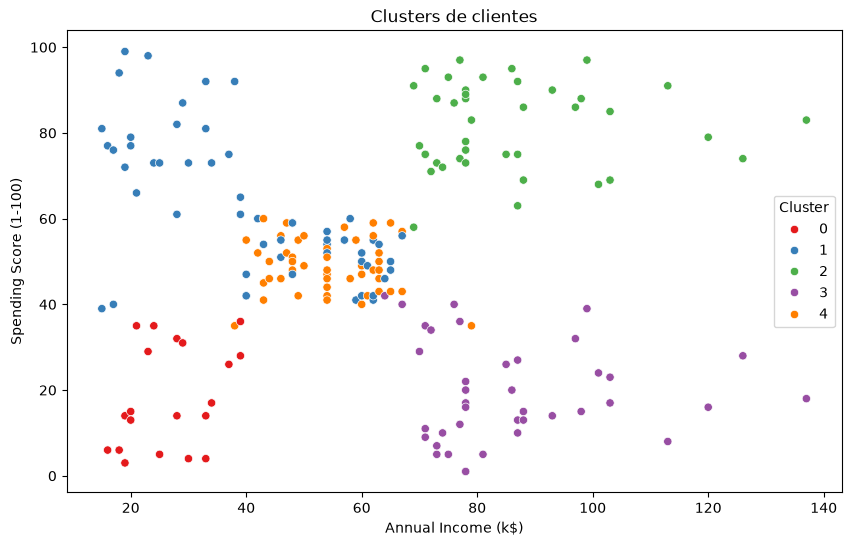

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Cluster', palette='Set1')
plt.title('Clusters de clientes')
plt.show()

## Optimizacion: el metodo del codo

La pregunta clave es **cual es el numero optimo de clusters**.

El *Elbow Method* ejecuta K-Means con `k` creciente y grafica el **WCSS**
(*Within-Cluster Sum of Squares*: la suma de distancias cuadradas de cada punto al
centroide de su cluster) contra el numero de clusters.

Buscamos el punto donde la curva pasa de una pendiente pronunciada a una suave —
el "codo" — porque a partir de ahi anadir mas clusters ya no mejora mucho la agrupacion.

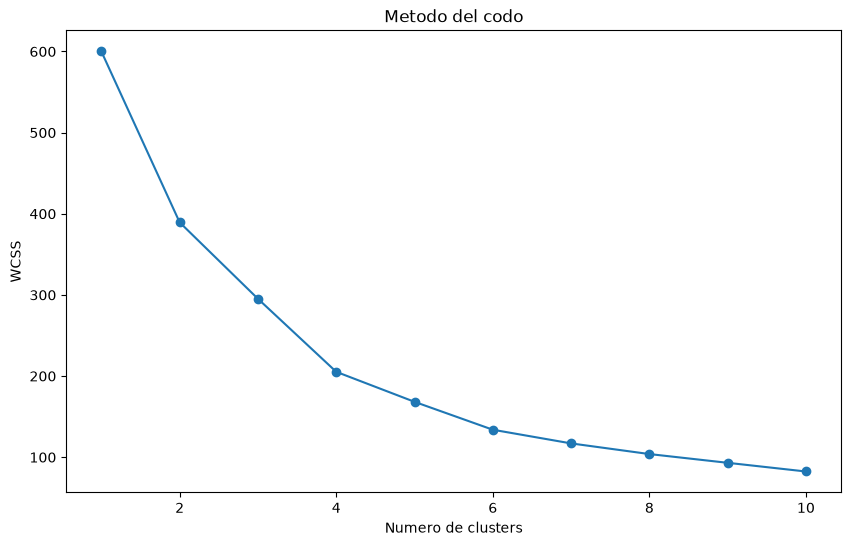

In [17]:
# Funcion para calcular la Suma de Cuadrados Dentro del Cluster (WCSS)
def calcular_wcss(datos):
    wcss = []
    for n in range(1, 11):
        kmeans = KMeans(n_clusters=n, init='k-means++', max_iter=300, n_init=10, random_state=42)
        kmeans.fit(datos)
        wcss.append(kmeans.inertia_)
    return wcss

# Calcular el WCSS para diferentes numeros de clusters
wcss = calcular_wcss(scaled_features)

# Graficar el metodo del codo
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Metodo del codo')
plt.xlabel('Numero de clusters')
plt.ylabel('WCSS')
plt.show()

La curva se quiebra alrededor de **k = 5 o 6**. Nos quedamos con **5 clusters** y
reajustamos el modelo definitivo.

## Modelo final con k = 5

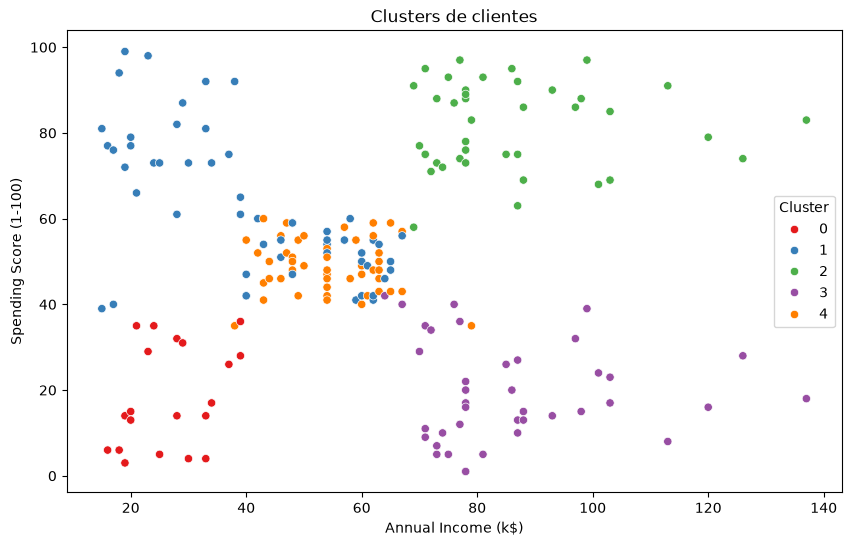

In [18]:
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters = kmeans.fit_predict(scaled_features)
df['Cluster'] = clusters

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Cluster', palette='Set1')
plt.title('Clusters de clientes')
plt.show()

## Visualizacion 3D

Como tenemos tres variables, podemos ver los clusters en su espacio completo.

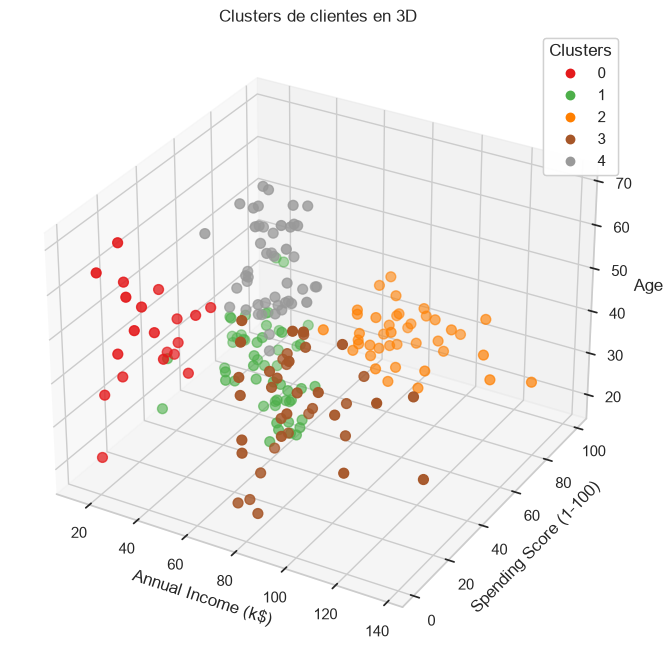

In [19]:
# Configurar el estilo de Seaborn
sns.set(style="whitegrid")

# Crear una figura en 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Grafico 3D de dispersion
scatter = ax.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], df['Age'],
                     c=df['Cluster'], cmap='Set1', s=50)

# Etiquetas de los ejes
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_zlabel('Age')

# Titulo de la grafica
ax.set_title('Clusters de clientes en 3D')

# Anadir la leyenda
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)

# Mostrar la grafica
plt.show()

## Analisis final

Calculamos el perfil promedio de cada cluster para poder hacer recomendaciones de negocio.

In [20]:
cluster_analysis = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']].groupby('Cluster').mean()
cluster_analysis

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064


In [21]:
for cluster in cluster_analysis.index:
    print(f"Cluster {cluster}:")
    print(f" - Edad promedio: {cluster_analysis['Age'][cluster]:.2f}")
    print(f" - Ingreso anual promedio: {cluster_analysis['Annual Income (k$)'][cluster]:.2f}k$")
    print(f" - Calificacion RetailMax promedio: {cluster_analysis['Spending Score (1-100)'][cluster]:.2f}")
    print("================================")

Cluster 0:
 - Edad promedio: 46.25
 - Ingreso anual promedio: 26.75k$
 - Calificacion RetailMax promedio: 18.35
Cluster 1:
 - Edad promedio: 25.19
 - Ingreso anual promedio: 41.09k$
 - Calificacion RetailMax promedio: 62.24
Cluster 2:
 - Edad promedio: 32.88
 - Ingreso anual promedio: 86.10k$
 - Calificacion RetailMax promedio: 81.53
Cluster 3:
 - Edad promedio: 39.87
 - Ingreso anual promedio: 86.10k$
 - Calificacion RetailMax promedio: 19.36
Cluster 4:
 - Edad promedio: 55.64
 - Ingreso anual promedio: 54.38k$
 - Calificacion RetailMax promedio: 48.85


### Tamano y composicion de cada segmento

El promedio por si solo no basta para priorizar: necesitamos saber **cuantos clientes**
hay en cada grupo y **cuanto ingreso agregado** representan.

In [22]:
perfil = df.groupby('Cluster').agg(
    clientes=('CustomerID', 'count'),
    edad_prom=('Age', 'mean'),
    ingreso_prom=('Annual Income (k$)', 'mean'),
    score_prom=('Spending Score (1-100)', 'mean'),
).round(2)

perfil['pct_base'] = (perfil['clientes'] / len(df) * 100).round(1)
perfil['pct_mujeres'] = (df.assign(f=df['Gender'].eq('Female')).groupby('Cluster')['f'].mean() * 100).round(1)

# Proxy del ingreso agregado que representa cada segmento
masa = perfil['clientes'] * perfil['ingreso_prom']
perfil['pct_ingreso_cartera'] = (masa / masa.sum() * 100).round(1)

perfil

,clientes,edad_prom,ingreso_prom,score_prom,pct_base,pct_mujeres,pct_ingreso_cartera
Cluster,,,,,,,
0,20,46.25,26.75,18.35,10.0,60.0,4.4
1,54,25.19,41.09,62.24,27.0,59.3,18.3
2,40,32.88,86.10,81.53,20.0,55.0,28.4
3,39,39.87,86.10,19.36,19.5,48.7,27.7
4,47,55.64,54.38,48.85,23.5,57.4,21.1


## Incorporando la variable "sexo"

Nos habiamos saltado `Gender` para evitar variables categoricas. Ahora la convertimos a
numerica (`Male` = 0, `Female` = 1) y reajustamos el modelo con las cuatro variables.

In [23]:
# Convertir a numerica
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# seleccion de features
extended_features = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# estandarizacion
scaled_extended_features = scaler.fit_transform(extended_features)

# Aplicar K-Means
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters_extended = kmeans.fit_predict(scaled_extended_features)

# Sustituir clusters anteriores
df['Cluster'] = clusters_extended

# analisis
extended_cluster_analysis = df[['Gender', 'Age', 'Annual Income (k$)',
                                'Spending Score (1-100)', 'Cluster']].groupby('Cluster').mean()
extended_cluster_analysis

,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,0.538462,32.692308,86.538462,82.128205
1,0.551724,36.482759,89.517241,18.000000
2,1.000000,49.813953,49.232558,40.069767
3,0.592593,24.907407,39.722222,61.203704
4,0.000000,55.714286,53.685714,36.771429


In [24]:
for cluster in extended_cluster_analysis.index:
    print(f"Cluster {cluster}:")
    print(f" - Edad promedio: {extended_cluster_analysis['Age'][cluster]:.2f}")
    print(f" - Ingreso anual promedio: {extended_cluster_analysis['Annual Income (k$)'][cluster]:.2f}k$")
    print(f" - Calificacion RetailMax promedio: {extended_cluster_analysis['Spending Score (1-100)'][cluster]:.2f}")
    print(f" - % mujeres: {extended_cluster_analysis['Gender'][cluster] * 100:.2f}%")
    print("================================")

Cluster 0:
 - Edad promedio: 32.69
 - Ingreso anual promedio: 86.54k$
 - Calificacion RetailMax promedio: 82.13
 - % mujeres: 53.85%
Cluster 1:
 - Edad promedio: 36.48
 - Ingreso anual promedio: 89.52k$
 - Calificacion RetailMax promedio: 18.00
 - % mujeres: 55.17%
Cluster 2:
 - Edad promedio: 49.81
 - Ingreso anual promedio: 49.23k$
 - Calificacion RetailMax promedio: 40.07
 - % mujeres: 100.00%
Cluster 3:
 - Edad promedio: 24.91
 - Ingreso anual promedio: 39.72k$
 - Calificacion RetailMax promedio: 61.20
 - % mujeres: 59.26%
Cluster 4:
 - Edad promedio: 55.71
 - Ingreso anual promedio: 53.69k$
 - Calificacion RetailMax promedio: 36.77
 - % mujeres: 0.00%


Al incluir el sexo, K-Means genera dos clusters que se separan **casi exclusivamente por
genero** (uno 100% mujeres y otro 0% mujeres) con perfiles de edad e ingreso muy parecidos
entre si. Es decir, la variable binaria escalada pesa tanto como las numericas y "gasta"
un cluster en dividir un grupo que en realidad era homogeneo en comportamiento de compra.

**Conclusion:** para segmentacion accionable conviene quedarse con el modelo de 3 variables
(edad, ingreso y spending score), y usar el sexo despues como variable descriptiva dentro de
cada segmento, no como variable de agrupamiento.

---

# Anexo: Reporte para el equipo de Marketing

El documento completo tambien esta disponible como archivo independiente en [`REPORTE.md`](./REPORTE.md).

# Segmentación de clientes RetailMax
## Reporte de recomendaciones para el equipo de Marketing

**Elaborado por:** Claudio Loza
**Área:** Analítica de datos
**Metodología:** Clustering K-Means (aprendizaje no supervisado)
**Base analizada:** 200 clientes registrados

---

## 1. Resumen ejecutivo

Se aplicó un modelo de segmentación no supervisada sobre la base de clientes de RetailMax con el objetivo de identificar grupos con comportamientos de compra homogéneos y, a partir de ellos, orientar la inversión de marketing. El análisis utilizó tres variables: edad, ingreso anual y calificación de gasto (*spending score*). El número óptimo de segmentos se determinó mediante el método del codo, que señaló **cinco clusters** como el punto donde agregar más grupos deja de aportar poder explicativo.

El hallazgo central del ejercicio es que **el poder adquisitivo no predice el gasto**. Los segmentos 2 y 3 registran exactamente el mismo ingreso anual promedio —86.10 mil dólares— pero calificaciones de gasto de 81.53 y 19.36 respectivamente. Ambos grupos concentran juntos el 56% del ingreso total de la cartera, pero solo uno de ellos lo está convirtiendo en ventas. Esta brecha constituye la principal oportunidad comercial detectada y debería concentrar el esfuerzo del próximo ciclo de campañas.

---

## 2. Descripción de los segmentos

| Cluster | Nombre propuesto | Clientes | % base | Edad prom. | Ingreso prom. | Score prom. |
|---|---|---|---|---|---|---|
| 2 | Premium activos | 40 | 20.0% | 32.9 | 86.10k$ | 81.53 |
| 3 | Potencial no capturado | 39 | 19.5% | 39.9 | 86.10k$ | 19.36 |
| 1 | Jóvenes de alta propensión | 54 | 27.0% | 25.2 | 41.09k$ | 62.24 |
| 4 | Maduros estables | 47 | 23.5% | 55.6 | 54.38k$ | 48.85 |
| 0 | Bajo compromiso | 20 | 10.0% | 46.3 | 26.75k$ | 18.35 |

---

## 3. Recomendaciones por segmento

### Prioridad 1 — Cluster 3: "Potencial no capturado" (39 clientes, 19.5%)

Es el segmento más rentable en potencia y el peor atendido hoy. Tiene el ingreso más alto de la cartera junto con el cluster 2, pero apenas gasta. Su edad promedio es siete años mayor que la de los Premium activos.

**Acciones recomendadas:**
1. **Investigación cualitativa previa a invertir.** Antes de lanzar promociones, aplicar entrevistas o encuestas a una muestra de este grupo. El bajo gasto con alto ingreso indica una barrera —surtido inadecuado, mala experiencia previa, preferencia por la competencia— que un descuento no resuelve.
2. **Evitar la promoción por precio.** El descuento es ineficaz en clientes cuya restricción no es económica, y erosiona margen sin necesidad.
3. **Probar propuesta de valor diferenciada:** categorías premium, atención personalizada, servicios de conveniencia (entrega programada, asesoría, personal shopper).

**Meta sugerida:** elevar el score promedio de 19 a 35 en doce meses. Dado que el segmento representa 27.7% del ingreso agregado de la cartera, incluso una conversión parcial supera el retorno de cualquier otra acción.

### Prioridad 2 — Cluster 2: "Premium activos" (40 clientes, 20.0%)

Alto ingreso y alto gasto. Es el segmento de mayor valor actual y el de mayor riesgo si se descuida.

**Acciones recomendadas:** programa de lealtad de nivel superior con beneficios exclusivos; acceso anticipado a lanzamientos y preventas; *upselling* y venta cruzada hacia categorías de mayor margen; comunicación de baja frecuencia pero alto valor. **La prioridad aquí es retención, no captación.** La pérdida de un cliente de este grupo equivale a la de cuatro del cluster 0.

### Prioridad 3 — Cluster 1: "Jóvenes de alta propensión" (54 clientes, 27.0%)

El segmento más numeroso. Ingreso medio-bajo (41.09k$) pero score de 62.24: gastan por encima de lo que su ingreso sugeriría. Alta propensión a comprar y trayectoria de ingreso creciente por delante.

**Acciones recomendadas:** promociones frecuentes y de ticket accesible; facilidades de pago (meses sin intereses); comunicación por canales digitales y redes sociales; **construcción de marca a largo plazo**, ya que al crecer su ingreso migrarán naturalmente hacia el perfil Premium. Es una inversión a futuro, no solo a resultado inmediato.

### Prioridad 4 — Cluster 4: "Maduros estables" (47 clientes, 23.5%)

Perfil intermedio en las tres variables y el de mayor edad (55.6 años). Constituye el núcleo estable del negocio.

**Acciones recomendadas:** programa de lealtad tradicional por acumulación de puntos; campañas estacionales; comunicación por canales convencionales (correo electrónico, punto de venta) más que digitales. Objetivo: mantener frecuencia, no forzar crecimiento.

### Prioridad 5 — Cluster 0: "Bajo compromiso" (20 clientes, 10.0%)

Ingreso y gasto bajos. Aporta 4.4% del ingreso agregado de la cartera.

**Acciones recomendadas:** mínimo esfuerzo dedicado. Incluir únicamente en campañas masivas de bajo costo marginal. **No se recomienda asignar presupuesto específico**, ya que el costo de adquisición difícilmente se recupera.

---

## 4. Consideraciones metodológicas

Se evaluó incorporar el **sexo** como variable de agrupamiento. El resultado no fue satisfactorio: al añadirla, el algoritmo generó dos clusters divididos casi exclusivamente por género —uno 100% mujeres y otro 0%— con perfiles de edad e ingreso prácticamente idénticos entre sí. Al ser una variable binaria estandarizada, adquiere un peso desproporcionado y consume un cluster en dividir un grupo que era homogéneo en comportamiento de compra.

**Recomendación:** conservar el modelo de tres variables para la segmentación, y utilizar el sexo como variable descriptiva dentro de cada segmento —para ajustar el tono creativo y la selección de medios— pero no como criterio de agrupamiento. Cabe señalar que ningún segmento del modelo final presenta un sesgo de género relevante: la proporción de mujeres oscila entre 48.7% y 60.0%, cercana al balance de la base total.

---

## 5. Limitaciones

Tres advertencias deben acompañar la lectura de estos resultados:

1. **Tamaño de muestra.** Doscientos clientes es una base reducida; el cluster 0 contiene solo veinte casos, por lo que sus promedios son sensibles a valores atípicos.
2. **Origen del *spending score*.** El modelo asume la calificación como un indicador válido de comportamiento de compra. Conviene documentar cómo se construye antes de tomar decisiones presupuestales sobre ella.
3. **Ausencia de variables transaccionales.** No se dispone de frecuencia de compra, ticket promedio, categorías adquiridas ni antigüedad del cliente. Incorporar un modelo **RFM** (Recencia, Frecuencia, Monto) enriquecería sustancialmente la segmentación.

---

## 6. Siguientes pasos propuestos

1. Validar los cinco segmentos con el equipo comercial y confirmar que corresponden a perfiles reconocibles en operación.
2. Ejecutar la investigación cualitativa sobre el cluster 3 antes de comprometer presupuesto.
3. Diseñar una campaña piloto por segmento con medición de resultados a noventa días.
4. Reevaluar el modelo semestralmente: la segmentación no es estática y los clientes migran entre grupos.
5. Ampliar la base de variables con información transaccional para una segunda iteración del modelo.

---

*Reporte generado a partir del análisis contenido en `2_clustering.ipynb`. Modelo K-Means, k=5, `random_state=42`, inercia final 168.25.*
